In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Border, Side, Alignment, Font
from openpyxl.utils import get_column_letter
from scipy.stats import beta
from scipy.optimize import curve_fit
import copy

from sklearn.metrics import r2_score

from collections import defaultdict
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')



In [3]:
def load_weather(weather_path, start_year, end_year):    
    # Load the "Hourly" weather data
    
    weather_data = pd.read_csv(weather_path)
    # Slicing the weather data to the dates within the observation year
    weather_data['Date'] = pd.to_datetime(weather_data['Date'], format="%d/%m/%Y", errors='coerce')
    weather_data = weather_data[
        (pd.to_datetime(weather_data['Date'],format="%d/%m/%Y") >= pd.to_datetime(f'{start_year}-1-1')) &
        (pd.to_datetime(weather_data['Date'],format="%d/%m/%Y") <= pd.to_datetime(f'{end_year}-12-31'))]       
    # Renaming the columns and add doy column         
    weather_data = weather_data[['Date', 'Time', 'Temp']].rename(columns={'Date': 'date', 'Time':'Time', 'Temp':'temp'}, inplace=False)
    weather_data.insert(1, 'doy', [d.dayofyear for d in pd.to_datetime(weather_data['date'], format="%d/%m/%Y")])
    # Interpolate missing values
    # Convert '-' to NaN
    weather_data['temp'].replace('-', np.nan, inplace=True)
    weather_data['temp']=weather_data['temp'].apply(pd.to_numeric, errors='coerce')

    # Interpolate missing values
    if weather_data['temp'].isna().any():
        weather_data['temp'].interpolate(method='linear', inplace=True)


    return weather_data.reset_index(drop=True) 

# For single temperature values
def Wangengel(T, MinTemp,OptTemp,MaxTemp,RefTemp):
    RelEff = 0.0
    RelEffRefTemp = 1.0
    p = 0.0

    if MinTemp < T < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEff = (2 * (T - MinTemp) ** p * (OptTemp - MinTemp) ** p - (T - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    if MinTemp < RefTemp < MaxTemp:
        p = math.log(2.0) / math.log((MaxTemp - MinTemp) / (OptTemp - MinTemp))
        RelEffRefTemp = (2 * (RefTemp - MinTemp) ** p * (OptTemp - MinTemp) ** p - (RefTemp - MinTemp) ** (2 * p)) / (OptTemp - MinTemp) ** (2 * p)

    return float(RelEff / RelEffRefTemp)


def cool_response_linear(T, T_crit=15.0, T_base=3.0):
    """
    Cool-weighted temperature response for Hayward SSC.
    
    Parameters
    ----------
    T : float or array
        Mean daily temperature (°C)
    T_crit : float
        Temperature above which SSC accumulation is inactive
    T_base : float
        Lower bound for full response
    
    Returns
    -------
    f : float or array
        Dimensionless daily forcing (0--1)
    """
    T = np.asarray(T)

    f = np.zeros_like(T, dtype=float)

    mask1 = (T < T_crit) & (T > T_base)
    f[mask1] = (T_crit - T[mask1]) / (T_crit - T_base)

    f[T <= T_base] = 1.0
    f[T >= T_crit] = 0.0

    return f

def linear_relationship(x,a,b):
    return a*x + b

In [4]:
file_path = './KRIP_hayward_fruit_quality_data/Trevelyans data 2023-2025.xlsx'
xls = pd.ExcelFile(file_path, engine="openpyxl")
Report = pd.read_excel(xls, sheet_name = 'HwMaturityAreas')


In [ ]:
# KwiStart: #18
# Mainpack: #21

list_of_interested_columns = ['GrowerMaCode',
                              'Sum of Season',
                            'FullBloomDate',
                            'ClearToPickDate',
                            'Sum of Brix',
                            'Sum of DryMatter',
                            'Sum of GirdleCountSize',
                            'Sum of GirdleCountDryMatter']

Report_KiwiStart = Report[(Report['Sum of IsKiwiStart']==1)][list_of_interested_columns].reset_index(drop=True)
Report_Mainpack = Report[(Report['Sum of IsKiwiStart']==0)][list_of_interested_columns].reset_index(drop=True)
DM_maurity = Report_KiwiStart[(Report_KiwiStart['Sum of GirdleCountDryMatter']==2)]['Sum of DryMatter']


In [6]:
Report_Mainpack

,GrowerMaCode,Sum of Season,FullBloomDate,ClearToPickDate,Sum of Brix,Sum of DryMatter,Sum of GirdleCountSize,Sum of GirdleCountDryMatter
0,18966_1,2023,2022-11-23,2023-05-24,8.9,17.8,1,2
1,18966_3,2023,2022-11-23,2023-05-24,8.5,17.6,1,2
2,18966_4,2023,2022-11-23,2023-05-24,8.8,17.1,1,2
3,64052_HWC,2023,2022-11-25,2023-05-19,8.6,18.0,1,1
4,64052_HWD,2023,2022-11-25,2023-05-19,8.8,18.1,1,1
5,75554_F,2023,2022-11-27,2023-05-20,8.4,17.5,1,2
6,75554_G,2023,2022-11-27,2023-05-20,8.2,17.7,1,2
7,18966_1,2024,2023-11-21,2024-05-16,10.2,18.6,1,1
8,18966_3,2024,2023-11-21,2024-05-16,9.9,18.5,1,1
9,18966_4,2024,2023-11-21,2024-05-16,10.2,18.5,1,1


In [46]:
check = Report_Mainpack[(Report_Mainpack['GrowerMaCode'].isin(['18966_1','18966_3','18966_4'])) & (Report_Mainpack['Sum of GirdleCountDryMatter']==1)]
check

,GrowerMaCode,Sum of Season,FullBloomDate,ClearToPickDate,Sum of Brix,Sum of DryMatter,Sum of GirdleCountSize,Sum of GirdleCountDryMatter
7,18966_1,2024,2023-11-21,2024-05-16,10.2,18.6,1,1
8,18966_3,2024,2023-11-21,2024-05-16,9.9,18.5,1,1
9,18966_4,2024,2023-11-21,2024-05-16,10.2,18.5,1,1
14,18966_1,2025,2024-11-23,2025-05-18,8.4,17.7,1,1
15,18966_3,2025,2024-11-23,2025-05-18,8.5,17.9,1,1
16,18966_4,2025,2024-11-23,2025-05-18,8.5,17.8,1,1


In [8]:
np.mean(pd.to_datetime(pd.Series(['2024-05-9','2024-05-15'])))

Timestamp('2024-05-12 00:00:00')

In [47]:
np.median([10.2,10.2,9.9])

np.float64(10.2)

In [10]:
season = 2025
# value = np.median(Report_KiwiStart[(Report_KiwiStart['Sum of Season']==season) & (Report_KiwiStart['Sum of GirdleCountDryMatter']==2)]['Sum of Brix'])
# date = np.mean(pd.to_datetime(Report_KiwiStart[(Report_KiwiStart['Sum of Season']==season) & (Report_KiwiStart['Sum of GirdleCountDryMatter']==2)]['ClearToPickDate']))
# print(f'KiwiSart ({season}): ', date, value)
# value = np.median(Report_Mainpack[(Report_Mainpack['Sum of Season']==season) & (Report_Mainpack['Sum of GirdleCountDryMatter']==2)]['Sum of Brix'])
# date = np.mean(pd.to_datetime(Report_Mainpack[(Report_Mainpack['Sum of Season']==season) & (Report_Mainpack['Sum of GirdleCountDryMatter']==2)]['ClearToPickDate']))
# print(f'Mainpack ({season}): ',date, value)

In [11]:
Report_KiwiStart[(Report_KiwiStart['Sum of Season'])==season]

,GrowerMaCode,Sum of Season,FullBloomDate,ClearToPickDate,Sum of Brix,Sum of DryMatter,Sum of GirdleCountSize,Sum of GirdleCountDryMatter
12,83765_A,2025,2024-11-29,2025-04-02,8.8,18.0,1,2
13,57575_1,2025,2024-11-12,2025-04-10,5.9,18.0,1,2
14,57575_2,2025,2024-11-12,2025-03-31,5.3,17.9,1,2
15,57575_3,2025,2024-11-12,2025-04-03,5.4,17.5,1,2
16,58585_HW2,2025,2024-11-17,2025-04-08,5.6,17.4,1,2
17,58585_HW1,2025,2024-11-17,2025-03-30,5.4,17.5,1,2


In [12]:
Report_Mainpack[(Report_Mainpack['Sum of Season']==season) & (Report_Mainpack['Sum of GirdleCountDryMatter']==2)]

,GrowerMaCode,Sum of Season,FullBloomDate,ClearToPickDate,Sum of Brix,Sum of DryMatter,Sum of GirdleCountSize,Sum of GirdleCountDryMatter
17,64052_HWC,2025,2024-11-22,2025-05-24,10.3,17.9,1,2
18,64052_HWD,2025,2024-11-22,2025-05-26,11.6,17.3,1,2
19,75554_F,2025,2024-11-30,2025-05-18,9.0,17.6,1,2
20,75554_G,2025,2024-11-30,2025-05-18,8.8,17.8,1,2


In [39]:
# THERMAL TIME ACCUMULATION
##########################################
weather_df = defaultdict(lambda: defaultdict(lambda: dict()))
weather_path= {'Kerikeri': "C:/Users/hranfs/Documents/VS code/Weather/Kerikeri_interpolated_hourly_2007_2024.csv",
                'Te Puke': "C:/Users/hranfs/Documents/VS code/Weather/Te Puke_interpolated_hourly_2007_2025.csv"}

location = 'Te Puke'
NumGirdleDM = [2]
season = 2025

# KIWISTART:
Kiwistart_RequiredTT = []

Report_KiwiStart_2GirdleDM = Report_KiwiStart[(Report_KiwiStart['Sum of GirdleCountDryMatter'].isin(NumGirdleDM)) ]
                                               # (Report_KiwiStart['Sum of Season'] == season)]

for i in range(len(Report_KiwiStart_2GirdleDM)):
    # FullBloom & Picking Dates
    FullBloomDate = pd.to_datetime(Report_KiwiStart_2GirdleDM['FullBloomDate'].iloc[i])
    ClearToPickDate = pd.to_datetime(Report_KiwiStart_2GirdleDM['ClearToPickDate'].iloc[i])

    # FullBloom & Picking Years
    flowering_year = FullBloomDate.year
    fruiting_year = ClearToPickDate.year

    # Load the weather data
    weather_data = load_weather(weather_path[location], flowering_year, fruiting_year)
    weather_data['date'] = pd.to_datetime(weather_data['date'], format="%d/%m/%Y") 
    weather_since_start_doy = weather_data[(weather_data['date']>=FullBloomDate) & (weather_data['date'] <=ClearToPickDate)].reset_index(drop=True)  
    
    TT = 0
    for temp in weather_since_start_doy['temp']:
        TT += Wangengel(temp, MinTemp=4,OptTemp=10,MaxTemp=16,RefTemp=10)

    Kiwistart_RequiredTT.append(TT)
    
# Mainpack:
Mainpack_RequiredTT = []

Report_Mainpack_2GirdleDM = Report_Mainpack[(Report_Mainpack['Sum of GirdleCountDryMatter'].isin(NumGirdleDM)) ] 
                                             #(Report_Mainpack['Sum of Season'] == season)]

for i in range(len(Report_Mainpack_2GirdleDM)):
    # FullBloom & Picking Dates
    FullBloomDate = pd.to_datetime(Report_Mainpack_2GirdleDM['FullBloomDate'].iloc[i])
    ClearToPickDate = pd.to_datetime(Report_Mainpack_2GirdleDM['ClearToPickDate'].iloc[i])

    # FullBloom & Picking Years
    flowering_year = FullBloomDate.year
    fruiting_year = ClearToPickDate.year

    # Load the weather data
    weather_data = load_weather(weather_path[location], flowering_year, fruiting_year)
    weather_data['date'] = pd.to_datetime(weather_data['date'], format="%d/%m/%Y") 
    weather_since_start_doy = weather_data[(weather_data['date']>=FullBloomDate) & (weather_data['date'] <=ClearToPickDate)].reset_index(drop=True)  
    
    TT = 0
    for temp in weather_since_start_doy['temp']:
        TT += Wangengel(temp, MinTemp=4,OptTemp=10,MaxTemp=16,RefTemp=10)

    Mainpack_RequiredTT.append(TT)
    

In [40]:
data_x = copy.deepcopy(Kiwistart_RequiredTT)
data_x.extend(Mainpack_RequiredTT)


data_y = list(copy.deepcopy(Report_KiwiStart_2GirdleDM['Sum of Brix']))
data_y.extend(Report_Mainpack_2GirdleDM['Sum of Brix'])


0.8617890291950292
4.549999999999999 13.500000000000002 139.99999999999997 815.7225955634854


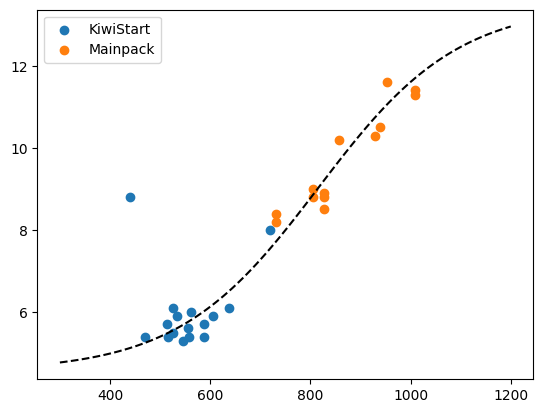

In [42]:
plt.scatter(Kiwistart_RequiredTT, Report_KiwiStart_2GirdleDM['Sum of Brix'], label='KiwiStart')
plt.scatter(Mainpack_RequiredTT, Report_Mainpack_2GirdleDM['Sum of Brix'], label='Mainpack')
plt.legend()

def ssc_sigmoid(CT,
                SSC_min,
                SSC_max,
                b,
                CT_crit):
    """
    Sigmoid SSC accumulation for Hayward kiwifruit.
    
    Parameters (R2=0.87)
    ----------
    CT : float or array
        Cumulative cool time
    SSC_min : float: 
        Lower asymptote (°Brix)
    SSC_max : float: 
        Upper asymptote (°Brix)
    b : float: 
        Inverse of Sigmoid slope
    CT_crit : float: 
        Inflection point
    
    Returns
    -------
    SSC : float or array
        Simulated soluble solids content (°Brix)
    """
    return SSC_min + (SSC_max - SSC_min) / (
        1.0 + np.exp(-(CT - CT_crit)/b))

bounds = [(4,13.5,130,600),(4.55,13.75,140,850)]
popt, _ = curve_fit(ssc_sigmoid, data_x, data_y, bounds=bounds)

x = np.linspace(300,1200,100)
plt.plot(x, ssc_sigmoid(x, popt[0], popt[1],popt[2], popt[3]), 'k--')
print(r2_score(data_y, [ssc_sigmoid(i, popt[0], popt[1],popt[2], popt[3]) for i in data_x]))
print(popt[0], popt[1],popt[2], popt[3])

In [ ]:
DM_maturity_2023 = Report_KiwiStart[(Report_KiwiStart['Sum of Season']==2023) & (Report_KiwiStart['Sum of GirdleCountDryMatter']==2)]['Sum of DryMatter'].median()
DM_maturity_2024 = Report_KiwiStart[(Report_KiwiStart['Sum of Season']==2024) & (Report_KiwiStart['Sum of GirdleCountDryMatter']==2)]['Sum of DryMatter'].median()
DM_maturity_2025 = Report_KiwiStart[(Report_KiwiStart['Sum of Season']==2025) & (Report_KiwiStart['Sum of GirdleCountDryMatter']==2)]['Sum of DryMatter'].median()

SSC_final_2023 = Report_Mainpack[(Report_Mainpack['Sum of Season']==2023) & (Report_Mainpack['Sum of GirdleCountDryMatter']==2)]['Sum of Brix'].median()
SSC_final_2024 = Report_Mainpack[(Report_Mainpack['Sum of Season']==2024) & (Report_Mainpack['Sum of GirdleCountDryMatter']==2)]['Sum of Brix'].median()
SSC_final_2025 = Report_Mainpack[(Report_Mainpack['Sum of Season']==2025) & (Report_Mainpack['Sum of GirdleCountDryMatter']==2)]['Sum of Brix'].median()

maturity_date_2023 = pd.to_datetime(Report_KiwiStart[(Report_KiwiStart['Sum of Season']==2023)]['ClearToPickDate']).mean()
maturity_date_2024 = pd.to_datetime(Report_KiwiStart[(Report_KiwiStart['Sum of Season']==2024)]['ClearToPickDate']).mean()
maturity_date_2025 = pd.to_datetime(Report_KiwiStart[(Report_KiwiStart['Sum of Season']==2025)]['ClearToPickDate']).mean()

harvest_date_2023 = pd.to_datetime(Report_Mainpack[(Report_Mainpack['Sum of Season']==2023)]['ClearToPickDate']).mean()
harvest_date_2024 = pd.to_datetime(Report_Mainpack[(Report_Mainpack['Sum of Season']==2024)]['ClearToPickDate']).mean()
harvest_date_2025 = pd.to_datetime(Report_Mainpack[(Report_Mainpack['Sum of Season']==2025)]['ClearToPickDate']).mean()

DM = [DM_maturity_2023,DM_maturity_2024,DM_maturity_2025]
SSC = [SSC_final_2023,SSC_final_2024,SSC_final_2025]

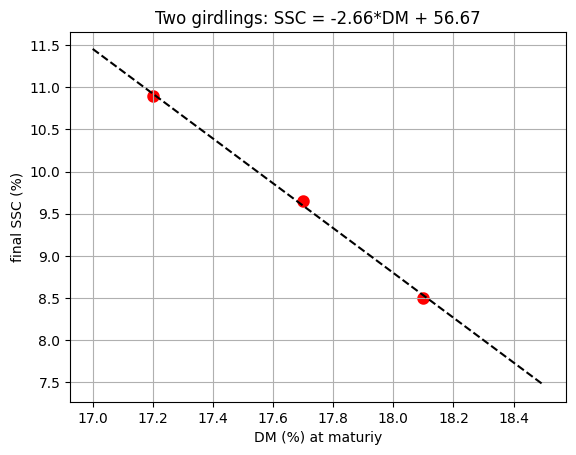

In [179]:
plt.scatter(DM,SSC, marker='o', linewidth = 3, color='r')
plt.xlabel('DM (%) at maturiy')
plt.ylabel("final SSC (%)")
plt.grid()

popt,_ = curve_fit(linear_relationship, DM, SSC)
x = np.linspace(17,18.5,50)
plt.plot(x, linear_relationship(x, popt[0], popt[1]), 'k--')
plt.title(f'Two girdlings: SSC = {popt[0]:.2f}*DM + {popt[1]:.2f}')
plt.show()

In [190]:
DM

[np.float64(18.1), np.float64(17.2), np.float64(17.7)]